In [1]:
import spacy
nlp = spacy.load("en_core_web_sm")
sentence = ('It has also arisen in criminal justice, healthcare, and hiring, '
            'compounding existing racial, economic, and gender biases')
doc = nlp(sentence)
tokens = [token.text for token in doc]
tokens

['It',
 'has',
 'also',
 'arisen',
 'in',
 'criminal',
 'justice',
 ',',
 'healthcare',
 ',',
 'and',
 'hiring',
 ',',
 'compounding',
 'existing',
 'racial',
 ',',
 'economic',
 ',',
 'and',
 'gender',
 'biases']

In [2]:
from collections import Counter
bag_of_words = Counter(tokens)
bag_of_words

Counter({',': 5,
         'and': 2,
         'It': 1,
         'has': 1,
         'also': 1,
         'arisen': 1,
         'in': 1,
         'criminal': 1,
         'justice': 1,
         'healthcare': 1,
         'hiring': 1,
         'compounding': 1,
         'existing': 1,
         'racial': 1,
         'economic': 1,
         'gender': 1,
         'biases': 1})

In [3]:
bag_of_words.most_common(3)

[(',', 5), ('and', 2), ('It', 1)]

In [4]:
import pandas as pd
most_common = dict(bag_of_words.most_common())
counts = pd.Series(most_common)
counts

,              5
and            2
It             1
has            1
also           1
arisen         1
in             1
criminal       1
justice        1
healthcare     1
hiring         1
compounding    1
existing       1
racial         1
economic       1
gender         1
biases         1
dtype: int64

In [5]:
len(counts)

17

In [6]:
counts.sum()

22

In [7]:
len(tokens)

22

In [8]:
counts/counts.sum()

,              0.227273
and            0.090909
It             0.045455
has            0.045455
also           0.045455
arisen         0.045455
in             0.045455
criminal       0.045455
justice        0.045455
healthcare     0.045455
hiring         0.045455
compounding    0.045455
existing       0.045455
racial         0.045455
economic       0.045455
gender         0.045455
biases         0.045455
dtype: float64

In [9]:
counts['justice']

1

In [10]:
counts['justice']/counts.sum()

0.045454545454545456

In [11]:
sentence = "Algorithmic bias has been cited in cases ranging from election outcomes to the spread of online hate speech."
tokens = [tok.text for tok in nlp(sentence)]
counts = Counter(tokens)
dict(counts)

{'Algorithmic': 1,
 'bias': 1,
 'has': 1,
 'been': 1,
 'cited': 1,
 'in': 1,
 'cases': 1,
 'ranging': 1,
 'from': 1,
 'election': 1,
 'outcomes': 1,
 'to': 1,
 'the': 1,
 'spread': 1,
 'of': 1,
 'online': 1,
 'hate': 1,
 'speech': 1,
 '.': 1}

In [12]:
import requests
url = ('https://gitlab.com/tangibleai/nlpia2/raw/main/src/nlpia2/ch03/bias_intro.txt')
response = requests.get(url)
response

<Response [200]>

In [14]:
bias_intro_bytes = response.content
bias_intro = response.text
assert bias_intro_bytes.decode() == bias_intro
bias_intro[:70]

'Algorithmic bias describes systematic and repeatable errors in a compu'

In [18]:
tokens = [tok.text for tok in nlp(bias_into)]
counts = Counter(tokens)
counts

Counter({',': 35,
         'of': 16,
         '.': 16,
         'to': 15,
         'and': 14,
         '\n': 14,
         'the': 13,
         'or': 11,
         'in': 10,
         'can': 7,
         'algorithms': 7,
         'bias': 6,
         'is': 6,
         'a': 5,
         'as': 5,
         'not': 4,
         '"': 4,
         'has': 4,
         'their': 4,
         'Algorithmic': 3,
         'that': 3,
         'outcomes': 3,
         'many': 3,
         'but': 3,
         'design': 3,
         'algorithm': 3,
         'unanticipated': 3,
         'data': 3,
         'social': 3,
         'from': 3,
         'algorithmic': 3,
         'been': 3,
         'are': 3,
         'cases': 3,
         'systematic': 2,
         'unfair': 2,
         'such': 2,
         'users': 2,
         'Bias': 2,
         'due': 2,
         'including': 2,
         'limited': 2,
         'used': 2,
         'platforms': 2,
         'have': 2,
         'ranging': 2,
         'biases': 2,
         'gend

In [19]:
counts.most_common(5)

[(',', 35), ('of', 16), ('.', 16), ('to', 15), ('and', 14)]

In [21]:
counts.most_common()[-4:]

[('inputs', 1), ('between', 1), ('same', 1), ('service', 1)]

In [24]:
docs = [nlp(s) for s in bias_intro.split('\n') if s.strip()]
counts = []
for doc in docs:
    counts.append(Counter([t.text.lower() for t in doc]))
df = pd.DataFrame(counts)
df = df.fillna(0).astype(int)
len(df)

16

In [25]:
df.head()

,algorithmic,bias,describes,systematic,and,repeatable,errors,in,a,computer,...,there,no,examine,network,interrelated,programs,inputs,between,same,service
0,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,1,0,0,3,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,1,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [26]:
docs[10]

It has also arisen in criminal justice, healthcare, and hiring, compounding existing racial, economic, and gender biases.

In [27]:
df.iloc[10]

algorithmic    0
bias           0
describes      0
systematic     0
and            2
              ..
programs       0
inputs         0
between        0
same           0
service        0
Name: 10, Length: 246, dtype: int32

In [28]:
docs_tokens = []
for doc in docs:
    docs_tokens.append([
        tok.text.lower() for tok in nlp(doc.text)])
len(docs_tokens[0])

27

In [29]:
all_doc_tokens = []
for tokens in docs_tokens:
    all_doc_tokens.extend(tokens)
len(all_doc_tokens)

482

In [30]:
vocab = set(all_doc_tokens)
vocab = sorted(vocab)
len(vocab)

246

In [31]:
len(all_doc_tokens)/len(vocab)

1.9593495934959348

In [32]:
vocab

['"',
 "'s",
 ',',
 '-',
 '.',
 '2018',
 ';',
 'a',
 'ability',
 'accurately',
 'across',
 'addressed',
 'advanced',
 'algorithm',
 'algorithmic',
 'algorithms',
 'also',
 'an',
 'analysis',
 'and',
 'anticipated',
 'application',
 'arbitrary',
 'are',
 'arisen',
 'arrests',
 'as',
 'audiences',
 'authority',
 'barrier',
 'be',
 'because',
 'become',
 'been',
 'behavior',
 'being',
 'between',
 'bias',
 'biases',
 'but',
 'by',
 'can',
 'cases',
 'certain',
 'change',
 'cited',
 'coded',
 'collected',
 'color',
 'complexity',
 'compounding',
 'comprehensive',
 'computer',
 'concerned',
 'considered',
 'contexts',
 'create',
 'criminal',
 'cultural',
 'darker',
 'data',
 'datasets',
 'decisions',
 'describes',
 'design',
 'discovering',
 'discrimination',
 'displace',
 'due',
 'easily',
 'economic',
 'election',
 'emerge',
 'emerging',
 'engine',
 'enter',
 'errors',
 'ethnicity',
 'european',
 'even',
 'examine',
 'existing',
 'expand',
 'expectations',
 'expertise',
 'faces',
 'facial

In [33]:
count_vectors = []
for tokens in docs_tokens:
    count_vectors.append(Counter(tokens))
tf = pd.DataFrame(count_vectors)
tf = tf.T.sort_index().T
tf = tf.fillna(0).astype(int)
tf

,"""",'s,",",-,.,2018,;,a,ability,accurately,...,way,ways,website,when,which,who,with,within,world,wrongful
0,0,0,1,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,3,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
2,0,0,5,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,0,1,1,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,4,0,1,0,0,0,1,0,...,0,1,0,0,1,0,1,0,1,0
7,0,0,3,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,1,2,1,1,0,2,1,0,0,...,0,0,0,0,0,1,0,0,0,0
9,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [34]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
np.set_printoptions(edgeitems=8)
corpus = [doc.text for doc in docs]
vectorizer = CountVectorizer()
vectorizer = vectorizer.fit(corpus)
count_vectors = vectorizer.transform(corpus)
count_vectors

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 376 stored elements and shape (16, 240)>

In [35]:
count_vectors.toarray()

array([[0, 0, 0, 0, 0, 0, 0, 1, ..., 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 2, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 1, ..., 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, ..., 0, 0, 0, 0, 1, 0, 0, 0],
       [1, 0, 0, 0, 1, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0, ..., 0, 0, 1, 0, 1, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, ..., 0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, ..., 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 1],
       [0, 0, 0, 0, 0, 0, 0, 1, ..., 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, ..., 1, 0, 0, 0, 0, 1, 0, 0]], dtype=i

In [40]:
v1 = np.arange(5)
v2 = pd.Series(reversed(range(5)))
slow_answer = sum([4.2 * (x1 * x2) for x1, x2 in zip(v1, v2)])
slow_answer

42.0

In [41]:
faster_answer = sum(4.2 * v1 * v2)
faster_answer

42.0

In [42]:
fastest_answer = 4.2 * v1.dot(v2)
fastest_answer

42.0

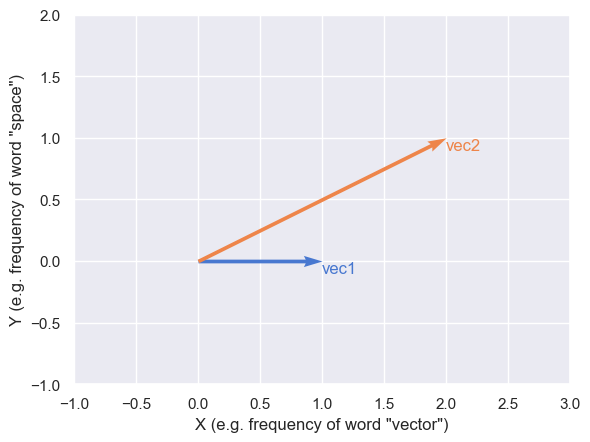

In [44]:
from matplotlib import pyplot as plt
import seaborn as sns

palette = sns.color_palette("muted")
sns.set_theme()

vecs = pd.DataFrame([[1,0], [2,1]], columns=['x', 'y'])
vecs['color'] = palette[:2]
vecs['label'] = [f'vec{i}' for i in range(1, len(vecs)+1)]

fig, ax = plt.subplots()
for i, row in vecs.iterrows():
    ax.quiver(0, 0, row['x'], row['y'], color=row['color'],
              angles='xy', scale_units='xy', scale=1)
    ax.annotate(row['label'], (row['x'], row['y']),
        color=row['color'], verticalalignment='top')
plt.xlim(-1, 3)
plt.ylim(-1, 2)
plt.xlabel('X (e.g. frequency of word "vector")')
plt.ylabel('Y (e.g. frequency of word "space")')
plt.show()

In [45]:
v1 = np.array([1,2,3])
v2 = np.array([2,3,4])
v1.dot(v2)

20

In [46]:
(v1*v2).sum()

20

In [47]:
sum([x1 * x2 for x1, x2 in zip(v1, v2)])

20

In [58]:
A.dot(B) == (np.linalg.norm(A) * np.linalg.norm(B)) * \
    np.cos(angle_between_A_and_B)

cos_similarity_between_A_and_B = np.cos(angle_between_A_and_B) \
    = A.dot(B) / (np.linalg.norm(A) * np.linalg.norm(B))

SyntaxError: cannot assign to function call (191842671.py, line 4)

In [59]:
import math
def cosine_sim(vec1, vec2):
    dot_prod = 0
    for x1, x2 in zip(vec1, vec2):
        dot_prod += x1 * x2

    mag_1 = math.sqrt(sum([x1**2 for x1 in vec1]))
    mag_2 = math.sqrt(sum([x2**2 for x2 in vec2]))

    return dot_prod / (mag_1 * mag_2)

In [ ]:
from sklearn.metrics.pairwise  import cosine_similarity
tf = tf.fillna(0)
vec1 = tf.values[:1,:]
vec2 = tf.values[1:2,:]
cosine_similarity(vec1, vec2)

array([[0.11785113]])

In [61]:
cosine_sim(vec1[0], vec2[0])

0.11785113019775792

In [62]:
import copy
question = "What is algorithmic bias?"
ngram_docs = copy.copy(docs)
ngram_docs.append(question)

question_vec = vectorizer.transform([question])
question_vec

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3 stored elements and shape (1, 240)>

In [63]:
question_vec.toarray()

array([[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]],
      dtype=int64)

In [64]:
vocab = list(zip(*sorted((i, tok) for tok, i in vectorizer.vocabulary_.items())))[1]
pd.Series(question_vec.toarray()[0], index=vocab).head(8)

2018           0
ability        0
accurately     0
across         0
addressed      0
advanced       0
algorithm      0
algorithmic    1
dtype: int64

In [66]:
cosine_similarity(count_vectors, question_vec)

array([[0.23570226],
       [0.12451456],
       [0.24743583],
       [0.4330127 ],
       [0.12909944],
       [0.16012815],
       [0.        ],
       [0.        ],
       [0.1490712 ],
       [0.27216553],
       [0.        ],
       [0.        ],
       [0.24077171],
       [0.14002801],
       [0.        ],
       [0.09128709]])

In [67]:
docs[3]

The study of algorithmic bias is most concerned with algorithms that reflect "systematic and unfair" discrimination.

In [68]:
ngram_vectorizer = CountVectorizer(ngram_range=(1, 2))
ngram_vectors = ngram_vectorizer.fit_transform(corpus)
ngram_vectors

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 772 stored elements and shape (16, 616)>

In [69]:
vocab = list(zip(*sorted((i, tok) for tok, i in ngram_vectorizer.vocabulary_.items())))[1]
pd.DataFrame(ngram_vectors.toarray(), columns=vocab)['algorithmic bias']

0     1
1     0
2     1
3     1
4     0
5     0
6     0
7     0
8     0
9     1
10    0
11    0
12    1
13    0
14    0
15    0
Name: algorithmic bias, dtype: int64

In [70]:
from this import s as secret
print(secret)

The Zen of Python, by Tim Peters

Beautiful is better than ugly.
Explicit is better than implicit.
Simple is better than complex.
Complex is better than complicated.
Flat is better than nested.
Sparse is better than dense.
Readability counts.
Special cases aren't special enough to break the rules.
Although practicality beats purity.
Errors should never pass silently.
Unless explicitly silenced.
In the face of ambiguity, refuse the temptation to guess.
There should be one-- and preferably only one --obvious way to do it.
Although that way may not be obvious at first unless you're Dutch.
Now is better than never.
Although never is often better than *right* now.
If the implementation is hard to explain, it's a bad idea.
If the implementation is easy to explain, it may be a good idea.
Namespaces are one honking great idea -- let's do more of those!
Gur Mra bs Clguba, ol Gvz Crgref

Ornhgvshy vf orggre guna htyl.
Rkcyvpvg vf orggre guna vzcyvpvg.
Fvzcyr vf orggre guna pbzcyrk.
Pbzcyrk vf or

In [71]:
from string import punctuation
punc = list(punctuation) + list(' \n')
def count_chars(text, tokenizer=list, token_pattern=None,
                stop_words=punc, **kwargs):
    lot = [text] if isinstance(text, str) else text #lot stands for list of texts
    vectorizer = CountVectorizer(
        token_pattern=token_pattern,
        stop_words=stop_words,
        tokenizer=tokenizer, #Defaults to tokenize str into character-grams, using tokenizer=list
        **kwargs)
    counts = vectorizer.fit_transform(lot)
    counts = counts.toarray()[0]
    vocab = vectorizer.vocabulary_
    index = pd.Series(vocab).sort_values().index
    counts = pd.Series(counts, index=index)
    return counts.sort_values()
secretcounts = count_chars(secret)
secretcounts

m     1
x     2
j     4
i     5
k     6
t    11
s    12
z    16
l    17
p    17
q    17
o    21
h    21
c    22
u    31
y    33
e    33
a    42
b    43
f    46
n    53
v    53
g    79
r    92
dtype: int64

In [75]:
import wikipedia as wiki
#page = wiki.page('machine learning') #connect time out
#mlcounts = count_chars(page.content)
page = open(r"nlpia2-main\src\nlpia2\data\wikiml.txt",'r',encoding='utf-8').read()
mlcounts = count_chars(page)
mlcounts

⇒       1
ń       1
’       1
—       2
”       7
“       7
–       7
        9
3      12
4      13
6      13
5      14
7      14
8      23
9      35
j      38
2      48
1      50
q      51
0      61
z      66
x     129
k     213
w     436
v     454
y     594
b     597
f     923
g    1074
u    1093
p    1107
m    1382
h    1569
d    1639
c    1788
l    2097
r    2997
s    3006
o    3108
t    3783
n    3824
i    4078
a    4146
e    5440
dtype: int64

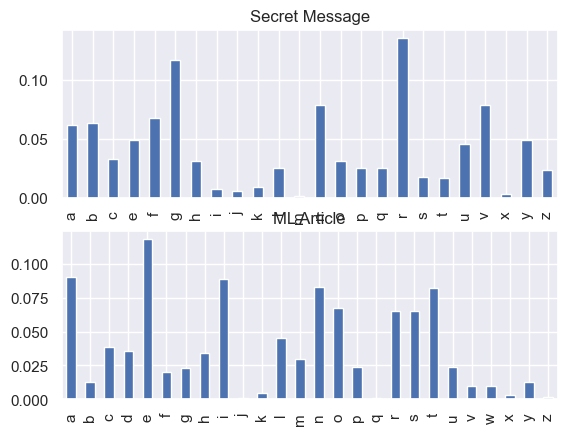

In [76]:
plt.subplot(2,1,1)
secretcounts /= secretcounts.sum()
secretcounts.sort_index()['a':'z'].plot(kind='bar', grid='on')
plt.title('Secret Message')
plt.subplot(2,1,2)
mlcounts /= mlcounts.sum()
mlcounts.sort_index()['a':'z'].plot(kind='bar', grid='on')
plt.title('ML Article')
plt.show()

In [77]:
peak_distance = ord('R') - ord('E')
peak_distance
chr(ord('v') - peak_distance)

'i'

In [78]:
chr(ord('n') - peak_distance)

'a'

In [79]:
import codecs
print(codecs.decode(secret, 'rot-13'))

The Zen of Python, by Tim Peters

Beautiful is better than ugly.
Explicit is better than implicit.
Simple is better than complex.
Complex is better than complicated.
Flat is better than nested.
Sparse is better than dense.
Readability counts.
Special cases aren't special enough to break the rules.
Although practicality beats purity.
Errors should never pass silently.
Unless explicitly silenced.
In the face of ambiguity, refuse the temptation to guess.
There should be one-- and preferably only one --obvious way to do it.
Although that way may not be obvious at first unless you're Dutch.
Now is better than never.
Although never is often better than *right* now.
If the implementation is hard to explain, it's a bad idea.
If the implementation is easy to explain, it may be a good idea.
Namespaces are one honking great idea -- let's do more of those!


In [80]:
import nltk
nltk.download('brown')

[nltk_data] Downloading package brown to C:\Users\throw\Study\Minicond
[nltk_data]     a\miniconda3\envs\nlpia2\nltk_data...
[nltk_data]   Unzipping corpora\brown.zip.


True

In [81]:
from nltk.corpus import brown
brown.words()[:10]

['The',
 'Fulton',
 'County',
 'Grand',
 'Jury',
 'said',
 'Friday',
 'an',
 'investigation',
 'of']

In [82]:
brown.tagged_words()[:5]

[('The', 'AT'),
 ('Fulton', 'NP-TL'),
 ('County', 'NN-TL'),
 ('Grand', 'JJ-TL'),
 ('Jury', 'NN-TL')]

In [83]:
len(brown.words())

1161192

In [84]:
from collections import Counter
puncs = set((',','.','--','-','!','?',':',';','``',"''",'(',')','[',']'))
word_list = (x.lower() for x in brown.words() if x not in puncs)
token_counts = Counter(word_list)
token_counts.most_common(10)

[('the', 69971),
 ('of', 36412),
 ('and', 28853),
 ('to', 26158),
 ('a', 23195),
 ('in', 21337),
 ('that', 10594),
 ('is', 10109),
 ('was', 9815),
 ('he', 9548)]

In [107]:
DATA_DIR = ('https://gitlab.com/tangibleai/nlpia/-/raw/master/src/nlpia/data')
url = DATA_DIR + '/bias_discrimination.txt'
bias_discrimination = requests.get(url).content.decode()
#bias_discrimination = open(r"nlpia2-main\src\nlpia2\ch03\bias_discrimination.txt",'r',encoding='utf-8').read() #数据有误
intro_tokens = [t.text for t in nlp(bias_intro.lower())]
disc_tokens = [t.text for t in nlp(bias_discrimination.lower())]
intro_total = len(intro_tokens)
intro_total

498

In [108]:
disc_total = len(disc_tokens)
disc_total #书中数据为9550

584

In [98]:
intro_tf = {}
disc_tf = {}
intro_counts = Counter(intro_tokens)
intro_tf['bias'] = intro_counts['bias'] / intro_total
disc_counts = Counter(disc_tokens)
disc_tf['bias'] = disc_counts['bias'] / disc_total
'Term Frequency of "bias" in intro is:{:.4f}'.format(intro_tf['bias'])

'Term Frequency of "bias" in intro is:0.0161'

In [99]:
'Term Frequency of "bias" in discrimination chapter is:{:.4f}'.format(disc_tf['bias'])

'Term Frequency of "bias" in discrimination chapter is:0.0000'

In [100]:
intro_tf['and'] = intro_counts['and'] / intro_total
disc_tf['and'] = disc_counts['and'] / disc_total
print('Term Frequency of "and" in intro is: {:.4f}'.format(intro_tf['and']))

Term Frequency of "and" in intro is: 0.0281


In [101]:
print('Term Frequency of "and" in discrimination chapter is: {:.4f}'.format(disc_tf['and']))

Term Frequency of "and" in discrimination chapter is: 0.0017


In [102]:
num_docs_containing_and = 0
for doc in [intro_tokens, disc_tokens]:
    if 'and' in doc:
        num_docs_containing_and += 1

In [103]:
intro_tf['black'] = intro_counts['black'] / intro_total
disc_tf['black'] = disc_counts['black'] /disc_total

In [104]:
num_docs = 2
intro_idf = {}
disc_idf = {}
intro_idf['and'] = num_docs / num_docs_containing_and
disc_idf['and'] = num_docs / num_docs_containing_and
intro_idf['bias'] = num_docs / num_docs_containing_bias
disc_idf['bias'] = num_docs / num_docs_containing_bias
intro_idf['black'] = num_docs / num_docs_containing_black
disc_idf['black'] = num_docs / num_docs_containing_black

NameError: name 'num_docs_containing_bias' is not defined

In [ ]:
intro_tfidf = {}
intro_tfidf['and'] = intro_tf['and'] * intro_idf['and']
intro_tfidf['bias'] = intro_tf['bias'] * intro_idf['bias']
intro_tfidf['black'] = intro_tf['black'] * intro_idf['black']

disc_tfidf = {}
disc_tfidf['and'] = disc_tf['and'] * disc_idf['and']
disc_tfidf['bias'] = disc_tf['bias'] * disc_idf['bias']
disc_tfidf['black'] = disc_tf['black'] * disc_idf['black']

In [ ]:
log_tf = log(term_occurences_in_doc) - log(num_terms_in_doc)
log_log_idf = log(log(totoal_num_docs) - log(num_docs_containing_term))
log_tf_idf = log_tf + log_log_idf

In [110]:
from sklearn.feature_extraction.text import TfidfVectorizer
#url = 'https://gitlab.com/tangibleai/community/knowt/-/raw/main/'
#url += '.knowt-data/corpus_hpr/sentences.csv?inline=false'
#df = pd.read_csv(url) #404 Not Found
docs = df['sentences']
vectorizer = TfidfVectorizer(min_df=1)
vectorizer = vectorizer.fit(docs)
vectors = vectorizer.transform(docs)

HTTPError: HTTP Error 404: Not Found

In [111]:
query_vec = vectorizer.transform(['where is the lost audio'])
query_vec

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 2 stored elements and shape (1, 240)>

In [112]:
dotproducts = query_vec.dot(vectors.T)
dotproducts.argmax()
idx = dotproducts.argmax()
idx

NameError: name 'vectors' is not defined

In [ ]:
df.iloc[idx]
df.iloc[i]['sentence']

In [113]:
DS_FAQ_URL = (r"nlpia2-main\src\nlpia2\data\faqbot.csv")
df = pd.read_csv(DS_FAQ_URL, index_col=0)

vectorizer = TfidfVectorizer()
vectorizer.fit(df['question'])
tfidfvectors_sparse = vectorizer.transform(df['question'])
tfidfvectors = tfidfvectors_sparse.todense()

def ask(question):
    question_vector = vectorizer.transform([question]).todense()
    idx = question_vector.dot(tfidfvectors.T).argmax()

    print(
        f"Your question:\n {question}\n\n"
        f"Most similar FAQ question:\n {df['question'][idx]}\n\n"
        f"Answer to that FAQ question:\n {df['answer'][idx]}\n\n")

ask("What's overfitting a model?")

Your question:
 What's overfitting a model?

Most similar FAQ question:
 What is overfitting?

Answer to that FAQ question:
 When your test set accuracy is significantly lower than your training set accuracy.




In [115]:
ask("What is a Gaussian distribution?")

Your question:
 What is a Gaussian distribution?

Most similar FAQ question:
 How do you tell if a distribution of values is Gaussian?

Answer to that FAQ question:
 P-value and T-test score above 0.05.




In [116]:
ask("How do I decrease overfitting for Logistic Regression?")

Your question:
 How do I decrease overfitting for Logistic Regression?

Most similar FAQ question:
 How to decrease overfitting in boosting models?

Answer to that FAQ question:
 What are some techniques to reduce overfitting in general? Will they work with boosting models?




In [119]:
question = 'LogisticRegression'
question_vector = vectorizer.transform([question])
dotproducts = question_vector.dot(tfidfvectors_sparse.T)
dotproducts = dotproducts.toarray()[0]
idx = dotproducts.argsort()[-3:]
idx

array([69, 35, 71], dtype=int64)

In [120]:
dotproducts[idx]

array([0.        , 0.2393827 , 0.34058149])

In [121]:
df['answer'][idx]

69    `[(country, len(group)) for country, group df....
35    A `LogisticRegression` will be less likely to ...
71    Decrease the C value, this increases the regul...
Name: answer, dtype: object